In [31]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict,Literal
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage,HumanMessage
from pydantic import BaseModel


In [32]:
generator=ChatGroq(model="qwen/qwen3.6-27b",temperature=0)
evaluator=ChatGroq(model="qwen/qwen3.6-27b",temperature=0)
optimizer=ChatGroq(model="qwen/qwen3.6-27b",temperature=0)

In [33]:
class TweetEvaluation(BaseModel):
    evaluation  :Literal["approved","not approved"]
    feedback : str

In [34]:
str_evaluator = evaluator.with_structured_output(TweetEvaluation)

In [35]:
class State(StateGraph):
    topic : str
    tweet : str
    iteration : int 
    max_iteration : int 
    feedback : str
    evaluation : Literal["approved","needs_improvements"]

In [36]:
graph = StateGraph(State)

In [37]:
def generate_tweet(state: State):
    #prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.|
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]
    response = generator.invoke(messages).content
    return {'tweet':response}

In [38]:
def evaluate_tweet(state:State):
    
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
    Evaluate the following tweet:

    Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]
    
    response = str_evaluator.invoke(messages)
    
    return {'evaluation': response['evaluation'],'feedback':response['feedback']}

In [39]:
def opimize_tweet(state : State):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [40]:
graph.add_node("generate",generate_tweet)
graph.add_node("evaluate",evaluate_tweet)
graph.add_node("optimize",opimize_tweet)

In [41]:
#funvction for check whether approved or not
def route_evaluator(state:State):
    if state['evaluation']=='approved' or state['iteration']>=state['max_iteration']:
        return "approved"
    else:
        return "not approved"

In [42]:
graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')

graph.add_conditional_edges('evaluate',route_evaluator,{'approved': END,'not apporved': 'optimize'})
graph.add_edge('optimize','evaluate')

In [43]:
workflow = graph.compile()

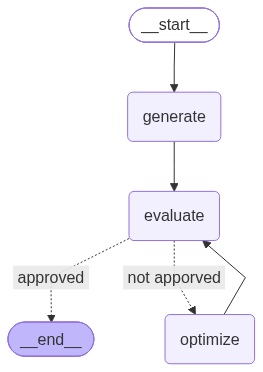

In [44]:
workflow

In [45]:
initial_state = {
    'topic' : "Indian Education System",
    'max_iteration' : 5,
    'iteration' : 1
}

final_state = workflow.invoke(initial_state)
final_state

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': 'evaluation: "needs_improvement"\nfeedback: "The tweet content is missing from your submission. Please provide the actual text so I can evaluate it against the criteria for originality, humor, punchiness, virality potential, and format. Without the content, it\'s impossible to determine if it meets the standards or triggers any auto-reject conditions."'}}